# **Gaussian processes (GP) with GPyTorch**  

Today we will use pytorch-based library GPyTorch for GP modeling.

GPyTorch is a flexible GP framework build upon Pytorch

📅 **Date:** [19/02/2026]  
🏫 **Email/Affiliation:** maria.ivanova@skoltech.ru

## **Introduction**  

A **Gaussian Process (GP)** is a powerful probabilistic model used in machine learning for regression and classification tasks. It provides a non-parametric approach to learning distributions over functions, making it particularly useful for modeling uncertainty and making predictions with confidence intervals.  

GPs are defined by a mean function and a covariance function (or kernel), which governs the smoothness and structure of the function space. A common choice is the **Radial Basis Function (RBF) kernel**, which ensures smooth and continuous predictions.  

Gaussian Processes are widely used in **Bayesian optimization**, **spatial data modeling**, and **time-series forecasting** due to their flexibility and ability to quantify uncertainty. However, they can be computationally expensive for large datasets, as they require inverting an $ N \times N $ covariance matrix, where $ N $ is the number of data points.  



## **Contents**  
1- Solving regression task using gaussian processes

2- Regression with GPyTorch. A simple example

3- Real world example, kernals, combining different kernals.

4- Bonus: an advanced example


📌 **Objective:** By the end of this seminar, you will understand Gaussian Processes for regression, learn to implement GPs using GPyTorch, explore real-world examples and kernel combinations.


In [1]:
!pip install gpytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.8/287.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.3/176.3 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 4.8 MB/s eta 0:00:00


## Solving regression task using gaussian processes

Gaussian Processes (GPs) provide a powerful non-parametric Bayesian approach to regression tasks. Unlike traditional regression models that assume a specific parametric form for f(x), GPs define a distribution over functions, allowing for flexible modeling of data with uncertainty quantification.


## Problem Setup  

We assume we have a dataset:  

$$
(\mathbf{X}, \mathbf{y}) = \left\{ (\mathbf{x}_i, y_i) \mid \mathbf{x}_i \in \mathbb{R}^d, y_i \in \mathbb{R} \right\}_{i=1}^{N}
$$  

where each input $\mathbf{x}_i$ is a $d$-dimensional vector, and the corresponding output $y_i$ is a scalar. We model the relationship between $\mathbf{x}$ and $y$ as follows:  

$$
y = f(\mathbf{x}) + \varepsilon
$$

where:  

- $f(\mathbf{x})$ is assumed to be a **Gaussian Process**,  
- $\varepsilon \sim 𝒩(\mathbf{0}, \sigma_\varepsilon^2)$ represents independent Gaussian noise with variance $\sigma_\varepsilon^2$.  

A Gaussian Process defines a **prior distribution** over functions, meaning that for any finite set of input points $\mathbf{X} = \{\mathbf{x}_1, \dots, \mathbf{x}_N\}$, the corresponding function values $f(\mathbf{X})$ follow a multivariate Gaussian distribution:  

$$
f(\mathbf{X}) \sim 𝒩(\mathbf{0}, \mathbf{K})
$$  

where $\mathbf{K}$ is the covariance matrix determined by a **kernel function** $k(\mathbf{x}, \mathbf{x}')$, which encodes the similarity between points.  

## Posterior Distribution for Prediction  

Given a new test input $\mathbf{x}_*$, our goal is to predict the output $y_*$. Under the Gaussian Process framework, the **posterior distribution** for $y_*$ is also Gaussian:  

$$
y_* | \mathbf{X}, \mathbf{y}, \mathbf{x}_* \sim 𝒩(\mu(\mathbf{x}_*), \sigma^2(\mathbf{x}_*))
$$  

where the mean and variance of the prediction are given by:  

$$
\mu(\mathbf{x}_*) = \mathbf{k}^T \mathbf{K}_y^{-1} \mathbf{y} = \sum_{i = 1}^N \alpha_i k(\mathbf{x}_*, \mathbf{x}_i),
$$

$$
\sigma^2(\mathbf{x}_*) = k(\mathbf{x}_*, \mathbf{x}_*) - \mathbf{k}^T\mathbf{K}_y^{-1}\mathbf{k}.
$$

where
$$
\mathbf{k} = \left ( k(\mathbf{x}_*, \mathbf{x}_1), \ldots, k(\mathbf{x}_*, \mathbf{x}_N) \right )^T
$$
$$
\mathbf{K}_y = \|k(\mathbf{x}_i, \mathbf{x}_j)\|_{i, j = 1}^N + \sigma_\varepsilon^2 \mathbf{I}
$$



### Exercises
We are given a set of observations $y_i = f(\mathbf{x}_i) + \varepsilon_i$, where $\varepsilon_i \sim 𝒩(0, \sigma^2)$.

1. What the posterior variance at the points from the training set is equal to? What if the noise variance is equal to 0?

2. Suppose that we want to minimize some unknown function $f(\mathbf{x})$.
   Using the observations we built a GP model $\hat{f}(\mathbf{x})$.
   Now, let us consider the value called *improvement*:
   $$
   I(\mathbf{x}) = \max(0, y^* - f(\mathbf{x}))$$
   where $y^*$ is currently found minimum value of $f(\mathbf{x})$.  
   To choose the next candidate for the minimum we would like to maximize the *Expected Improvement*
   $$
       EI(x) = \mathbb{E}_f I(\mathbf{x})
   $$

   1. Express the $EI(\mathbf{x})$ in terms $\Phi(\cdot)$ and $\phi(\cdot)$ - the cdf and pdf of the standard normal distribution $𝒩(0, 1)$.
   2. Assuming $\sigma = 0$ what is the value of $EI(\mathbf{x})$ for any value $y_i$ from the dataset?
   
### Solution

1. As $\mathbf{K}$ is real symmetric matrix: $\mathbf{K} = U D U^\top$. Then for the $i$-th point from the dataset we have
$$
\begin{align}
    \mathbb{Var}(\mathbf{x}_i) = \sigma^2(\mathbf{x}_i) &= k(\mathbf{x}_i, \mathbf{x}_i) - \mathbf{k}^\top (\mathbf{K} + \sigma^2_\epsilon I)^{-1} \mathbf{k} \\
    &= U_i D U_i^\top - U_i D U^\top (UDU^\top + \sigma^2_\epsilon I)^{-1} U D U_i^\top \\
    &= U_i ( D - D U^\top (U^\top)^{-1}(D + \sigma^2_\epsilon I)^{-1})U^{-1} U D) U_i^\top \\
    &= U_i D~diag\left(1 - \frac{d_j}{d_j + \sigma^2_\epsilon}\right)~U_i^\top < U_i D U_i^\top = k(\mathbf{x}_i, \mathbf{x}_i)
\end{align}
$$
If $\sigma^2_\epsilon = 0$, then $\sigma^2(x_i) = 0$.

2. Let $\mu$ and $\sigma$ are mean and the variance of the GP $f(\mathbf{x})$ at point $\mathbf{x}$. Then we can standardize it: $z = \frac{f - \mu}{\sigma} \sim 𝒩(0, 1)$. We only get positive improvement if the random $f(x)$ falls below $y^*$:
   $$
   \begin{align}
       EI(\mathbf{x}) &= \int_{-\infty}^{y^*} (y^* - f)p(f)df = \int_{-\infty}^{(y^* - \mu) / \sigma}(y^* - \sigma z - \mu)\phi(z)dz \\
       &= (y^* - \mu) \Phi\left(\frac{y^* - \mu}{\sigma}\right) - \int_{-\infty}^{(y^* - \mu) / \sigma} \sigma z \phi(z)dz \\
       &=\left\{\phi(z) = \frac{1}{\sqrt{2\pi}} e^{-z^2/2}, \quad \frac{d}{dz}\phi(z)
= \frac{1}{\sqrt{2\pi}}(-z)e^{-z^2/2}
= -z\,\phi(z) \right\} \\
       &= (y^* - \mu) \Phi\left(\frac{y^* - \mu}{\sigma}\right) + \int_{-\infty}^{(y^* - \mu) / \sigma} \sigma d(\phi(z)) \\
       &= (y^* - \mu) \Phi\left(\frac{y^* - \mu}{\sigma}\right) + \sigma \phi\left(\frac{y^* - \mu}{\sigma}\right)
   \end{align}
   $$
   If $\sigma_n = 0$, then $EI(\mathbf{x}_i) = \max(y^* - \mu(\mathbf{x}_i), 0)$

## Regression with GPyTorch. A simple example
Here we want to model following function:
$$
\begin{align}
y &= \sin(2\pi x) + \varepsilon \\
  \varepsilon &\sim 𝒩(0, 0.04)
\end{align}
$$

with $100$ training, и $51$ testing examples.


In [30]:
import math
import torch
import numpy as np
import gpytorch
from matplotlib import pyplot as plt

%matplotlib inline
#%load_ext autoreload
#%autoreload 2

In [31]:
# Training data is 100 points in [0,1] inclusive regularly spaced
train_x = torch.linspace(0, 1, 100)
# True function is sin(2*pi*x) with Gaussian noise
train_y = torch.sin(train_x * (2 * math.pi)) + torch.randn(train_x.size()) * math.sqrt(
    0.04
)

### Defining GPyTorch model

In order to obtain GP model in GPyTorch we need to define following objects:

1. **GP Model** (`gpytorch.models.ExactGP`) -  Performs predictions.
1. **Likelihood** (`gpytorch.likelihoods.GaussianLikelihood`) - Defines likelihood function for paremeter optimization:
$$\log p(y \mid X, \theta)
=
-\frac{1}{2}\,(y - \mu_\theta(X))^\top (K_\theta + \sigma_n^2 I)^{-1} (y - \mu_\theta(X))
-\frac{1}{2}\,\log\!\left|K_\theta + \sigma_n^2 I\right|
-\frac{n}{2}\log(2\pi)$$
1. **Mean** - Defines prior mean ($\mu_\theta (X)$) for $f(x)$.
1. **Kernel** - Defines kernel for covariance matrix computation (for example, RBF kernel is $k_\theta(x_i, x_j) = \sigma_f^2 \exp\!\left( -\frac{\lVert x_i - x_j \rVert^2}{2\ell^2} \right)$).
1. **MultivariateNormal** Distribution (`gpytorch.distributions.MultivariateNormal`) - Object, used to define multivariate gaussian distribution.


In [32]:
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, covar_module):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = covar_module

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

### Working modes

As in most PyTorch modules, `ExactGP` has `.train()` and `.eval()` modes.
- `.train()` mode used during parameter optimization.
- `.eval()` this is used when compution posterior distribution.

### Model training
In following code we will maximize dataset likelihood in order to obtain parameters of kernel and noise

In [37]:
def train_model(model, likelihood, train_x, train_y, training_iter=50, verbose=True):
    # Find optimal model hyperparameters
    model.train()
    likelihood.train()

    # Use the adam optimizer
    optimizer = torch.optim.Adam(
        model.parameters(), lr=0.1
    )  # Includes GaussianLikelihood parameters

    # "Loss" for GPs - the marginal log likelihood
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(training_iter):
        # Zero gradients from previous iteration
        optimizer.zero_grad()
        # Output from model
        output = model(train_x)
        # Calc loss and backprop gradients
        loss = -mll(output, train_y)
        loss.backward()
        if verbose:
            print(
                "Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f" #  mean: %.3f   var: %.3f
                % (
                    i + 1,
                    training_iter,
                    loss.item(),
                    #model.mean_module.constant.item(),
                    #model.covar_module.outputscale.item(),
                    model.covar_module.base_kernel.lengthscale.item(),
                    model.likelihood.noise.item(),
                )
            )
        optimizer.step()

In [38]:
# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
model = ExactGPModel(train_x, train_y, likelihood, covar_module)
train_model(model, likelihood, train_x, train_y, training_iter=50)

Iter 1/50 - Loss: 0.940   lengthscale: 0.693   noise: 0.693
Iter 2/50 - Loss: 0.908   lengthscale: 0.644   noise: 0.644
Iter 3/50 - Loss: 0.874   lengthscale: 0.598   noise: 0.598
Iter 4/50 - Loss: 0.836   lengthscale: 0.555   noise: 0.554
Iter 5/50 - Loss: 0.794   lengthscale: 0.514   noise: 0.513
Iter 6/50 - Loss: 0.746   lengthscale: 0.475   noise: 0.474
Iter 7/50 - Loss: 0.696   lengthscale: 0.439   noise: 0.437
Iter 8/50 - Loss: 0.644   lengthscale: 0.404   noise: 0.402
Iter 9/50 - Loss: 0.595   lengthscale: 0.372   noise: 0.369
Iter 10/50 - Loss: 0.550   lengthscale: 0.342   noise: 0.339
Iter 11/50 - Loss: 0.510   lengthscale: 0.315   noise: 0.310
Iter 12/50 - Loss: 0.473   lengthscale: 0.292   noise: 0.284
Iter 13/50 - Loss: 0.438   lengthscale: 0.272   noise: 0.259
Iter 14/50 - Loss: 0.404   lengthscale: 0.256   noise: 0.237
Iter 15/50 - Loss: 0.371   lengthscale: 0.243   noise: 0.216
Iter 16/50 - Loss: 0.338   lengthscale: 0.232   noise: 0.196
Iter 17/50 - Loss: 0.306   length

### Predictions with GPytorch model

In code below we will perform predictions at new points. To do so, we need to switch model and likelihood into eval mode and call both on test data.

In eval mode GP model returns `MultivariateNormal`, which contains posterior mean and variance.

Let us denote (`test_x`) as `x*`, and target value as `y*`. In this notation `model(test_x)` return posterior on values of function $f$: `p(f* | x*, X, y)`, where `X, y` is training data.

Contrary, `likelihood(model(test_x))` yields posterior predictive distribution of target value `y^*`: `p(y* | x*, X, y)`, which we want to predict.


Predictive mean, variance, as well as, GP posterior function samples at test points can be obtained with following code:

```python
f_preds = model(test_x)
y_preds = likelihood(model(test_x))

f_mean = f_preds.mean
f_var = f_preds.variance
f_covar = f_preds.covariance_matrix
f_samples = f_preds.sample(sample_shape=torch.Size(1000,))
```


In [10]:
# Get into evaluation (predictive posterior) mode
model.eval()
likelihood.eval()

# Test points are regularly spaced along [0,1]
# Make predictions by feeding model through likelihood
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    test_x = torch.linspace(0, 1, 51)
    observed_pred = likelihood(model(test_x))

### Prediction visualization

In [11]:
def plot_model(
    observed_pred, train_x, train_y, test_x, test_x_real=None, test_y_real=None
):
    with torch.no_grad():
        # Initialize plot
        f, ax = plt.subplots(1, 1, figsize=(8, 6))

        # Get upper and lower confidence bounds
        lower, upper = observed_pred.confidence_region()
        # Plot training data as black stars
        ax.plot(train_x.numpy(), train_y.numpy(), ".")
        # Plot predictive means as blue line
        ax.plot(test_x.numpy(), observed_pred.mean.numpy())
        # Shade between the lower and upper confidence bounds
        ax.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
        if test_x_real is not None:
            ax.plot(test_x_real, test_y_real, ".", color="tab:green")
            ax.legend(["Observed Data", "Mean", "True", "Confidence"])
        else:
            ax.legend(["Observed Data", "Mean", "Confidence"])
        return ax

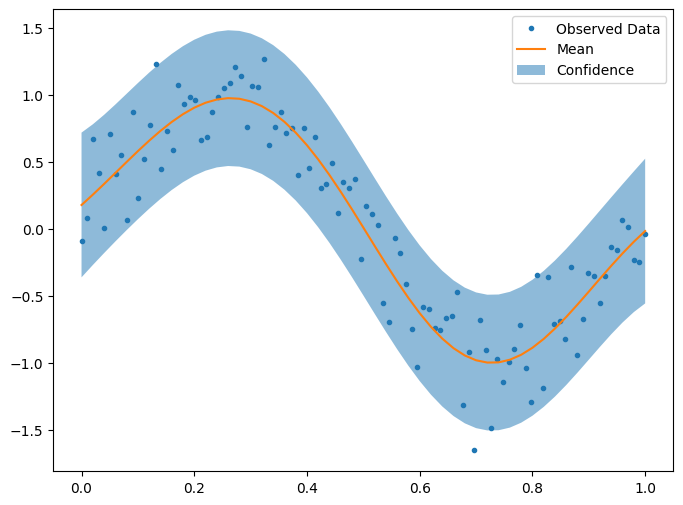

In [12]:
f = plot_model(observed_pred, train_x, train_y, test_x)

## Real world example

Construction of GP model for number of passengers of planes.

In [15]:
!wget https://github.com/adasegroup/ML2020_seminars/raw/master/seminar11/data/airline.npz

--2026-02-18 21:48:28--  https://github.com/adasegroup/ML2020_seminars/raw/master/seminar11/data/airline.npz
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/adasegroup/ML2020_seminars/master/seminar11/data/airline.npz [following]
--2026-02-18 21:48:29--  https://raw.githubusercontent.com/adasegroup/ML2020_seminars/master/seminar11/data/airline.npz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2514 (2.5K) [application/octet-stream]
Saving to: ‘airline.npz’

airline.npz         100%[===================>]   2.46K  --.-KB/s    in 0s      

2026-02-18 21:48:29 (48.4 MB/s) - ‘airline.npz’ saved [251

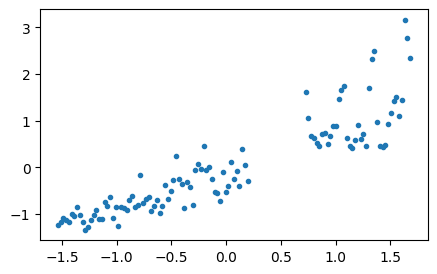

In [16]:
data = np.load("airline.npz")

X = data["X"][:, 0]
y = data["y"][:, 0]

train_indices = list(range(70)) + list(range(90, 129))
test_indices = range(70, 90)
X_train = X[train_indices]
y_train = y[train_indices]

# normalize data
mean_x = np.mean(X_train)
std_x = np.std(X_train)

mean_y = np.mean(y_train)
std_y = np.std(y_train)

X_train = (X_train - mean_x) / std_x
y_train = (y_train - mean_y) / std_y


X_test = (X[test_indices] - mean_x) / std_x
y_test = (y[test_indices] - mean_y) / std_y

plt.figure(figsize=(5, 3))
plt.plot(X_train, y_train, ".")
plt.show()

In [17]:
train_x = torch.tensor(X_train, dtype=torch.float32)
train_y = torch.tensor(y_train, dtype=torch.float32)
test_x_real = torch.tensor(X_test)
test_y_real = torch.tensor(y_test)
test_x = (torch.linspace(1948, 1964, 400, dtype=torch.float32) - mean_x) / std_x

### RBF kernel

In [18]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
covar_module = gpytorch.kernels.RBFKernel()
model = ExactGPModel(train_x, train_y, likelihood, covar_module)
train_model(model, likelihood, train_x, train_y, training_iter=50)

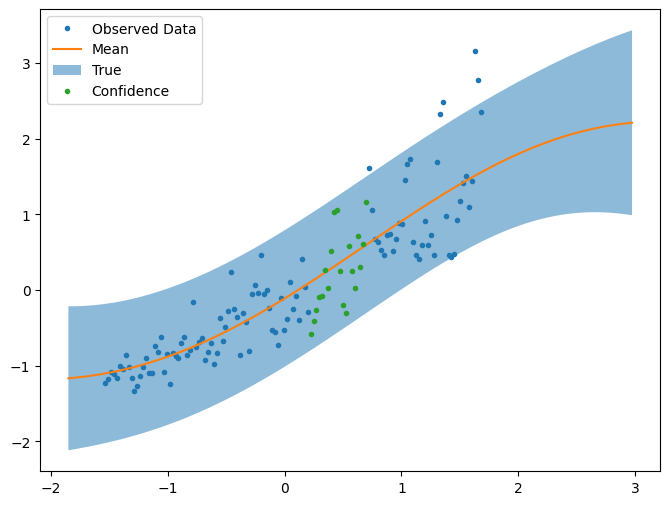

In [19]:
model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = likelihood(model(test_x))

ax = plot_model(observed_pred, train_x, train_y, test_x, test_x_real, test_y_real)

### Combining different kernels

Let us combine linear kernel, which picks up on trends, periodic kernel, which notice data seasonality, and RBF kernel, used to capture local nonlinearity.  
For more information see:
https://distill.pub/2019/visual-exploration-gaussian-processes/

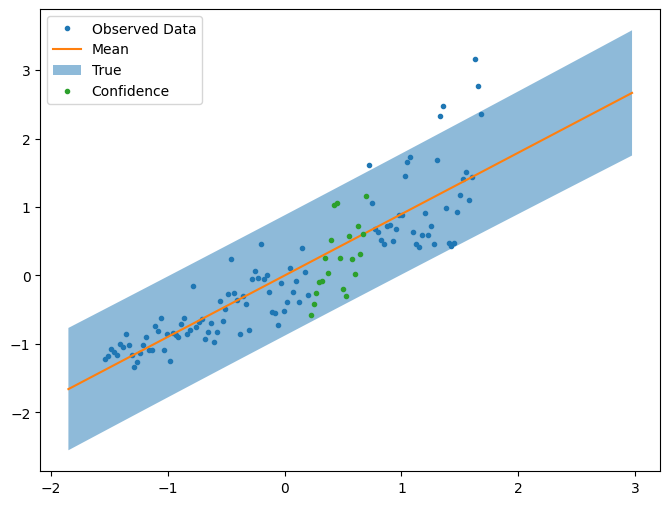

In [20]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
covar_module = gpytorch.kernels.LinearKernel()
# covar_module = gpytorch.kernels.ScaleKernel(covar_module)
model = ExactGPModel(train_x, train_y, likelihood, covar_module)
train_model(model, likelihood, train_x, train_y, training_iter=150)

model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = likelihood(model(test_x))

ax = plot_model(observed_pred, train_x, train_y, test_x, test_x_real, test_y_real)

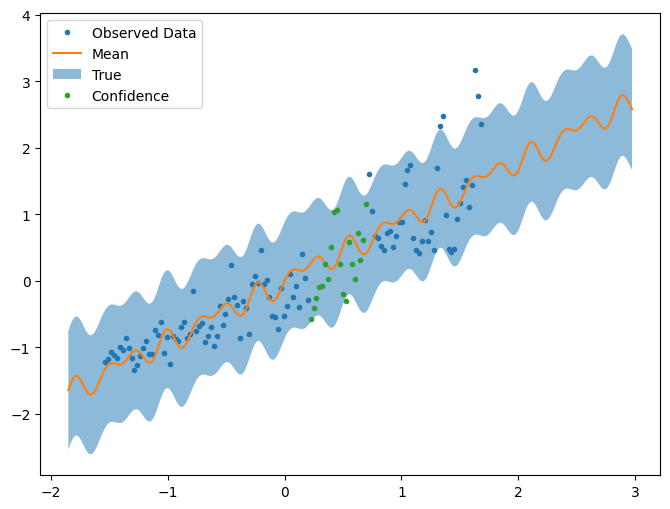

In [21]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
covar_module = gpytorch.kernels.LinearKernel() + gpytorch.kernels.PeriodicKernel()
# covar_module = gpytorch.kernels.ScaleKernel(covar_module)
model = ExactGPModel(train_x, train_y, likelihood, covar_module)
train_model(model, likelihood, train_x, train_y, training_iter=150)

model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = likelihood(model(test_x))

ax = plot_model(observed_pred, train_x, train_y, test_x, test_x_real, test_y_real)

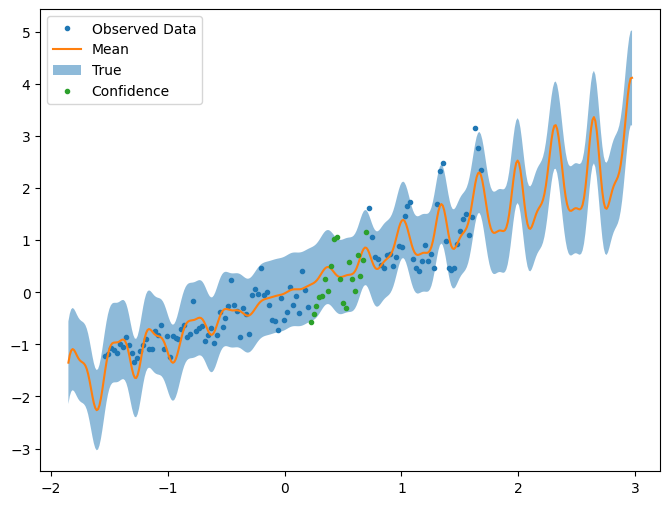

In [22]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
covar_module = gpytorch.kernels.LinearKernel() * gpytorch.kernels.PeriodicKernel()
# covar_module = gpytorch.kernels.ScaleKernel(covar_module)
model = ExactGPModel(train_x, train_y, likelihood, covar_module)
train_model(model, likelihood, train_x, train_y, training_iter=150)

model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = likelihood(model(test_x))

ax = plot_model(observed_pred, train_x, train_y, test_x, test_x_real, test_y_real)

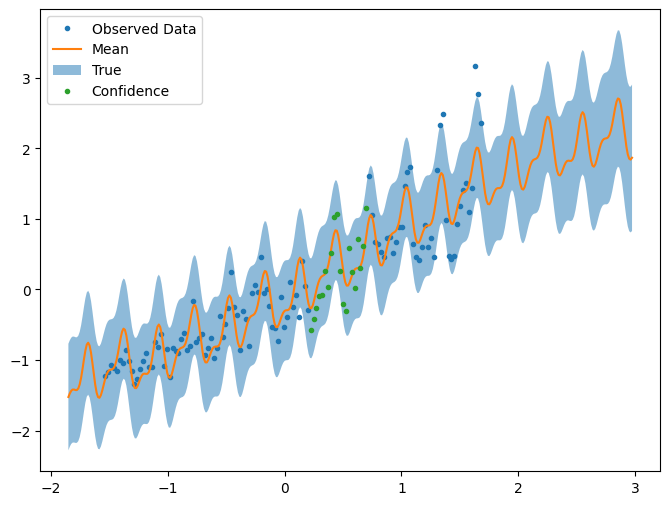

In [23]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
covar_module = gpytorch.kernels.PeriodicKernel() + gpytorch.kernels.RBFKernel()
# covar_module = gpytorch.kernels.ScaleKernel(covar_module)
model = ExactGPModel(train_x, train_y, likelihood, covar_module)
train_model(model, likelihood, train_x, train_y, training_iter=150)

model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = likelihood(model(test_x))

ax = plot_model(observed_pred, train_x, train_y, test_x, test_x_real, test_y_real)

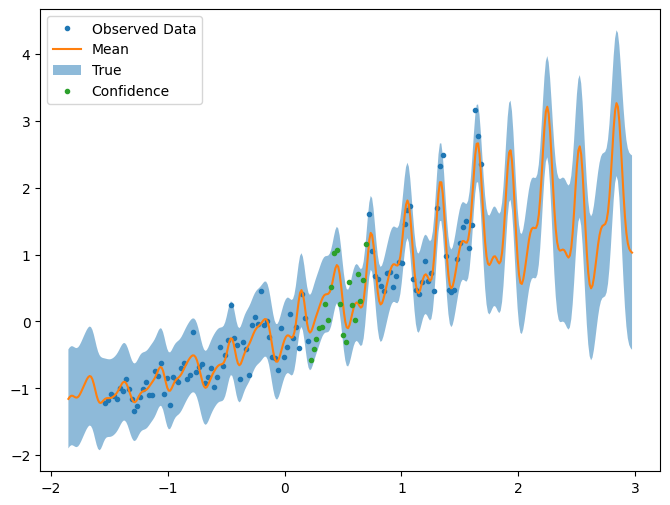

In [24]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
covar_module = gpytorch.kernels.PeriodicKernel() * gpytorch.kernels.RBFKernel()
# covar_module = gpytorch.kernels.ScaleKernel(covar_module)
model = ExactGPModel(train_x, train_y, likelihood, covar_module)
train_model(model, likelihood, train_x, train_y, training_iter=150)

model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = likelihood(model(test_x))

ax = plot_model(observed_pred, train_x, train_y, test_x, test_x_real, test_y_real)

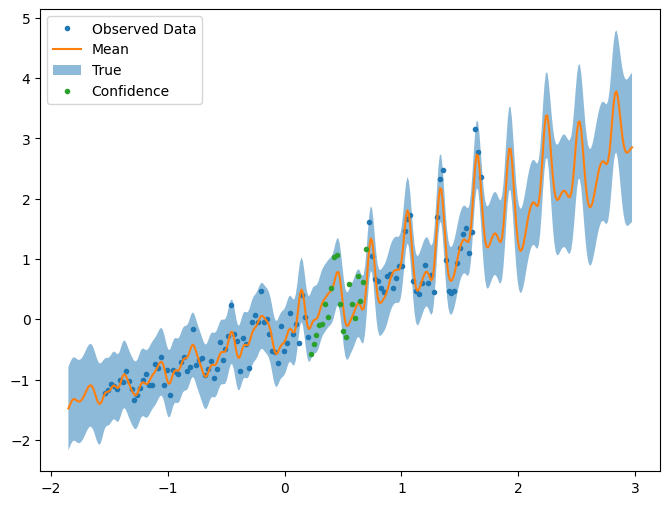

In [25]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
covar_module = gpytorch.kernels.ScaleKernel(
    gpytorch.kernels.LinearKernel() * gpytorch.kernels.RBFKernel()
)
covar_module += gpytorch.kernels.ScaleKernel(
    gpytorch.kernels.PeriodicKernel() * gpytorch.kernels.RBFKernel()
)
covar_module += gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
covar_module = gpytorch.kernels.ScaleKernel(covar_module)
model = ExactGPModel(train_x, train_y, likelihood, covar_module)
train_model(model, likelihood, train_x, train_y, training_iter=150)

model.eval()
likelihood.eval()

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    observed_pred = likelihood(model(test_x))

ax = plot_model(observed_pred, train_x, train_y, test_x, test_x_real, test_y_real)

# Conclustion

In this seminar, we explored Gaussian Processes (GPs) as a powerful Bayesian approach for modeling uncertainty in data. We discussed the fundamentals of GPs, their implementation using the GPyTorch library, and the role of kernels in defining function priors. Additionally, we examined the combination of kernels to enhance model expressiveness and applied these concepts to both synthetic and real-world datasets. Through these discussions, we highlighted the flexibility and scalability of GPs, demonstrating their potential in various machine learning applications.